<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/main/Aprendizaje%20Supervisado/Practico%201/AS_2026_Entregable_Grupo_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

### Grupo 3:

- Mariano Baggini
- DA SILVA, Rocio
- GRUZYCKI, Sergio
- NEDEL, Agustina

---
## Kaggle Competition: Clasificación de imágenes de rostros con o sin barbijos

**Objetivos especificos**:

- Explorar los datos y aprender de ellos.
- Probar diferentes modelos y ver cuáles ajustan mejor dado los datos.
- Para esta competencia se elige como métrica el **balanced_accuracy_score**. Discutir, analizar y justificar porque es necesaria está métrica para este problema.
- **Obtener una métrica mejor que la que se presenta en este ejemplo.**
- Tratar de obtener un score lo más alto posible!
- Discutir la elección de modelo.

NOTA: El análisis exploratorio y el preprocesamiento de los datos queda a libertad de cada grupo y no deben quedarse con este simple ejemplo.

In [ ]:
# Librerias usadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, classification_report, precision_score, accuracy_score, balanced_accuracy_score, f1_score
from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

sns.set_context('talk')

## 1. Carga de datos


### 1.1 Datos de entrenamiento

Cargamos los datos de entrenamiento que vamos a utilizar para generar nuestro modelo.

***Atributos del dataset:***

- `Id`: identificador unico de la imagen.
- `Clase`: etiqueta objetivo: ccb (cara con barbijo) o csb (cara sin barbijo).
- `bb_width`: ancho del recorte de la cara (bounding box).
- `bb_height`: alto de recorte de la cara.
- `ch_RGB`: promedio del histograma de los tres canales de color RGB.
- `1097`, `595`, ...: vector de caracteristicas numéricas extraído por la red convolucional.

In [ ]:
train_url = 'https://raw.github.com/DiploDatos/AprendizajeSupervisado/master/Pr%C3%A1ctico/mask_prediction_datasetDrop_train-labeled2.csv'
train_data = pd.read_csv(train_url, delimiter=';')

In [ ]:
train_df = train_data.copy()
train_df.head(2)

,id,clase,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,...,1152,1428,182,488,1369,582,570,2022,1966,198
0,1,ccb,118,167,126.002029,0.171342,0.254909,1.729943,0.872499,0.645055,...,0.000246,0.081324,0.391930,0.247319,0.033110,0.394890,0.204616,1.668020,0.052727,0.302152
1,2,ccb,286,396,152.522842,0.172407,0.217375,2.900968,0.421334,0.270867,...,0.056044,0.059036,0.123057,0.462978,0.037138,0.658777,0.172517,0.507375,0.274298,0.648528


In [ ]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Columns: 438 entries, id to 198
dtypes: float64(434), int64(3), str(1)
memory usage: 6.3 MB


La columna `clase` es la columna que debemos predecir. En el dataset de Test esta columna tiene valores nulos.

### 1.2 Datos de testeo

Cargamos los datos de test. Estos datos son los que van a utilizar para predecir si las personas tienen barbijos colocados en el rostro y generar alrchivo `submision.csv` para utilizar en la competencia de Kaggle.

In [ ]:
test_url = 'https://raw.github.com/DiploDatos/AprendizajeSupervisado/master/Pr%C3%A1ctico/mask_prediction_datasetDrop_train-labeled2.csv'
test_data = pd.read_csv(test_url, delimiter=';')

In [ ]:
test_df = test_data.copy()
test_df.head(2)

,id,clase,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,...,1152,1428,182,488,1369,582,570,2022,1966,198
0,1,ccb,118,167,126.002029,0.171342,0.254909,1.729943,0.872499,0.645055,...,0.000246,0.081324,0.391930,0.247319,0.033110,0.394890,0.204616,1.668020,0.052727,0.302152
1,2,ccb,286,396,152.522842,0.172407,0.217375,2.900968,0.421334,0.270867,...,0.056044,0.059036,0.123057,0.462978,0.037138,0.658777,0.172517,0.507375,0.274298,0.648528


In [ ]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Columns: 438 entries, id to 198
dtypes: float64(434), int64(3), str(1)
memory usage: 6.3 MB


### 1.3 Consideraciones generales

Cada fila representa la imagen de una cara ya procesada por la ResNet. Las columnas `bb_width`, `bb_height` y `ch_RGB` son features interpretables, mientras que el resto son las 434 activaciones extraídas por la red convolucional. Si bien estas no tienen una interpretacion individual directa, se utilizan para capturar patrones visuales aprendidos por el modelo.

Recapitulando el tamaño de los datasets:

In [ ]:
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (1884, 438)
Test shape : (1884, 438)


## 2. Analisis de los datos

### 2.1 Exploracion inicial

In [ ]:
resnet_cols = [c for c in train_df.columns if c not in ['id', 'clase', 'bb_width', 'bb_height', 'ch_RGB']]

In [ ]:
# Nulos en train y test
print("Nulos en train:", train_df.isnull().sum().sum())
print("Nulos en test :", test_df.isnull().sum().sum())
print("\nNulos por columna en test (solo las que tienen):")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Nulos en train: 0
Nulos en test : 0

Nulos por columna en test (solo las que tienen):
Series([], dtype: int64)


Se observa que el conjunto de entrenamiento no tiene ningún valor nulo. Por otro lado, el conjunto test tiene la columna de interes `clase` vacía a propósito. Las demás features están completas en ambos conjuntos, no es necesario imputar.

In [ ]:
# Estudio de duplicados
print("Filas duplicadas (train) :", train_df.duplicated().sum())
print("IDs duplicados   (train) :", train_df['id'].duplicated().sum())
print("IDs duplicados    (test) :", test_df['id'].duplicated().sum())

Filas duplicadas (train) : 0
IDs duplicados   (train) : 0
IDs duplicados    (test) : 0


No se encontraron filas ni IDs duplicados en train ni test.

In [ ]:
# Estadisticas descriptivas
train_df.describe()

,id,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,1448,...,1152,1428,182,488,1369,582,570,2022,1966,198
count,1884.000000,1884.000000,1884.00000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,...,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000
mean,942.500000,101.909236,133.47983,114.109534,0.168035,0.400830,1.690452,0.296696,0.445435,0.442737,...,0.066285,0.171946,0.215352,0.416790,0.085017,0.320012,0.318657,0.693318,0.223473,0.250213
std,544.008272,91.933372,119.15816,30.696614,0.126249,0.273933,1.219991,0.213530,0.406341,0.284700,...,0.069526,0.179459,0.209379,0.278408,0.086755,0.221458,0.231352,0.457887,0.116369,0.161713
min,1.000000,11.000000,12.00000,40.301282,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000246,0.000000,0.000648,0.000000,0.001931,0.007359,0.000000
25%,471.750000,48.750000,59.00000,92.309942,0.075003,0.199049,0.547147,0.135446,0.115591,0.237259,...,0.015967,0.058051,0.064764,0.194096,0.023932,0.152957,0.141901,0.331458,0.133532,0.129353
50%,942.500000,71.000000,88.00000,109.841245,0.143056,0.336917,1.631053,0.251868,0.342227,0.381312,...,0.045157,0.119384,0.147675,0.360841,0.057883,0.271596,0.274714,0.618690,0.214287,0.219952
75%,1413.250000,120.000000,167.00000,134.545488,0.234480,0.541367,2.653032,0.400949,0.644068,0.569638,...,0.095316,0.217514,0.307282,0.593489,0.117845,0.435103,0.450637,0.946997,0.296023,0.336383
max,1884.000000,1296.000000,1070.00000,202.392985,0.991374,1.821444,5.263674,1.397370,2.541877,2.500119,...,0.538534,1.363758,1.493638,1.545518,0.859438,1.943598,1.753040,3.450385,0.627220,1.135739


Se observa que `bb_width` y `bb_height` tienen rangos muy amplios (de 11 a 1296 y de 12 a 1070), lo que indica que hay tamaño dispares según la resolución del video/frame original. Las features de la ResNet están en escalas más pequeñas y homogéneas entre sí. Estudiamos en mayor detalle los features interpretables:

In [ ]:
train_df[['bb_width', 'bb_height', 'ch_RGB']].describe()

,bb_width,bb_height,ch_RGB
count,1884.000000,1884.00000,1884.000000
mean,101.909236,133.47983,114.109534
std,91.933372,119.15816,30.696614
min,11.000000,12.00000,40.301282
25%,48.750000,59.00000,92.309942
50%,71.000000,88.00000,109.841245
75%,120.000000,167.00000,134.545488
max,1296.000000,1070.00000,202.392985


Al observar las columnas, se nota una diferencia de escalas entre columnas. Esto da la pauta de la necesidad de estandarizacion posterior.

### 2.2 Estudio de desbalance

Veamos de que manera se distribuyen los datos en los valores del feature objetivo: `clase`.

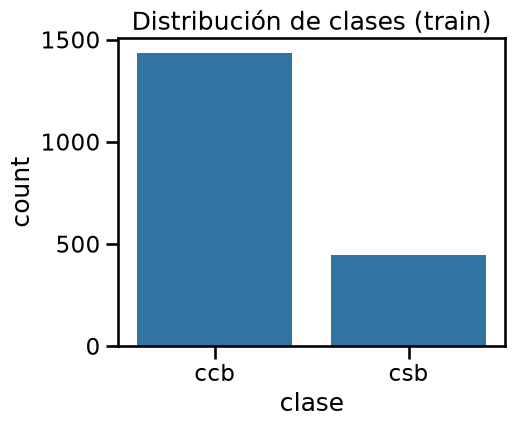

In [ ]:
# Estudio de desbalance
plt.figure(figsize=(5,4))
sns.countplot(data=train_df, x='clase')
plt.title('Distribución de clases (train)')
plt.show()

In [ ]:
# Distribucion de datos
conteo = train_df['clase'].value_counts()
porcentaje = (train_df['clase'].value_counts(normalize='True')*100).round(2)

tabla_distribucion = pd.DataFrame({
    'Frecuencia':conteo,
    'Porcentaje (%)':porcentaje
})

tabla_distribucion

,Frecuencia,Porcentaje (%)
clase,,
ccb,1436,76.22
csb,448,23.78


Debido al desbalance presente (relacion 4:1), es de gran importancia que el modelo sea preciso al identificar la clase minoritaria. De otra forma, sus metricas resultan engañosas aunque sean elevadas.

### 2.3 EDA: Essential features

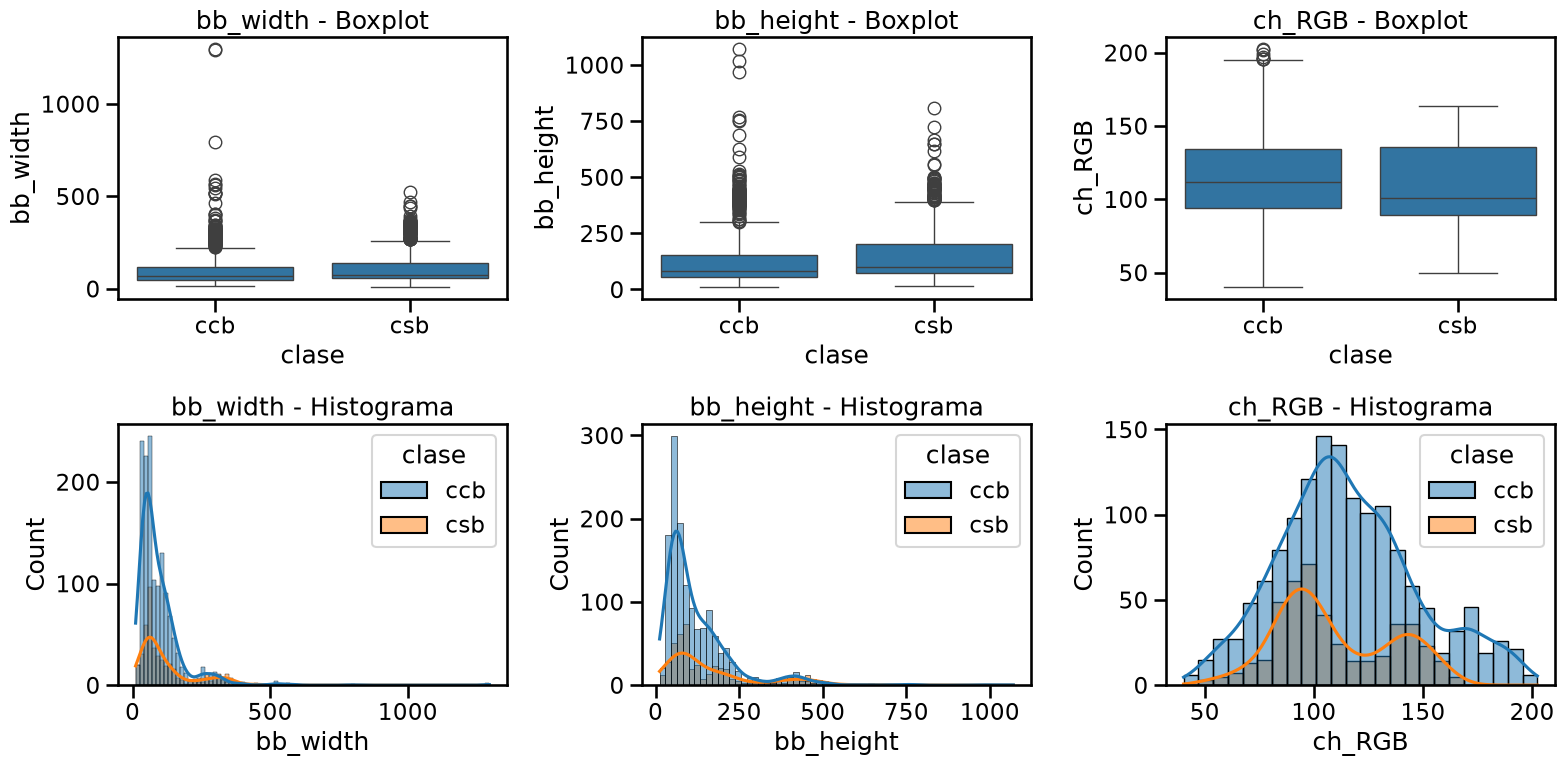

In [ ]:
# Distribución de features por clase
features_simples = ['bb_width', 'bb_height', 'ch_RGB']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(features_simples):
    sns.boxplot(data=train_df, x='clase', y=col, ax=axes[0,i])
    axes[0,i].set_title(f'{col} - Boxplot')

    sns.histplot(data=train_df, x=col, hue='clase', kde=True, ax=axes[1,i])
    axes[1,i].set_title(f'{col} - Histograma')
plt.tight_layout()
plt.show()

Tanto en `bb_width` como en `bb_height`, la clase *csb* presenta medianas levemente más altas que *ccb*, aunque las cajas se superponen significativamente y ambas clases tienen colas largas de valores atípicos. En `ch_RGB` las distribuciones de ambas clases son idénticas, por lo que el color promedio parece no discriminar bien entre tener o no tener barbijo.

Los histogramas demuestran que se ve una superposición entre *ccb* y *csb* en las 3 features, con la clases *ccb* dominando por ser mayoritaria.

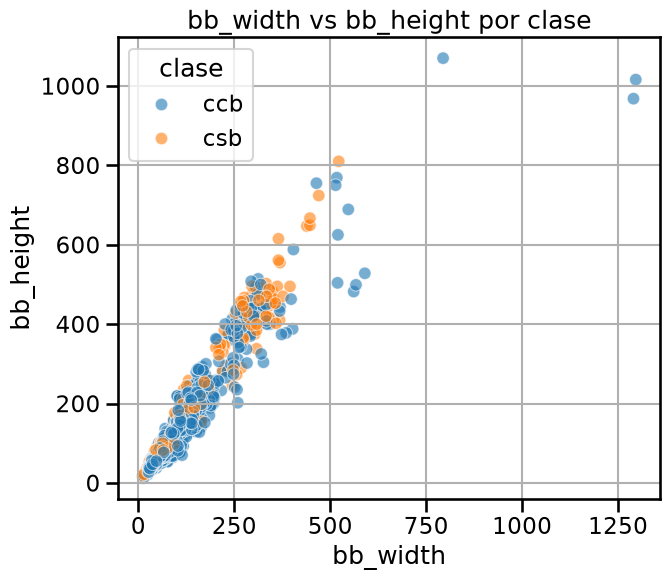

In [ ]:
# Relacion entre bounding box
plt.figure(figsize=(7,6))
sns.scatterplot(data=train_df, x='bb_width', y='bb_height', hue='clase', alpha=0.6)
plt.title('bb_width vs bb_height por clase')
plt.grid()
plt.show()

Se observa una relacion lineal entre `bb_width` y `bb_height`, como era de esperarse. No se observa una separación clara entre clases, los puntos están entremezclados.

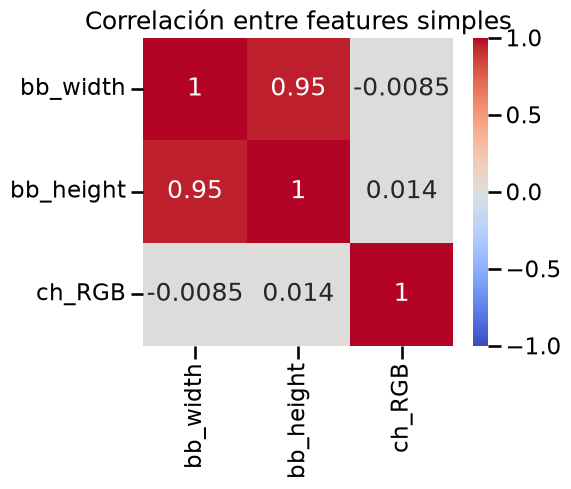

In [ ]:
# Correlacion entre features simple
plt.figure(figsize=(5,4))
sns.heatmap(train_df[features_simples].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre features simples')
plt.show()

Se ve que `bb_width` y `bb_height` están correlacionados entre sí, ambas aportan la misma información. Podría considerarse combinarlas en una sola feature, pero por el momento no se hará esto. Por otro lado, `ch_RGB` no tiene correlación con ninguna de las dos, es una feature independiente del tamaño.

Features con menor varianza:
273     0.002161
1379    0.004530
1152    0.004834
1200    0.005330
1138    0.006626
748     0.007087
1369    0.007526
1976    0.008188
1463    0.008443
1823    0.008900
dtype: float64


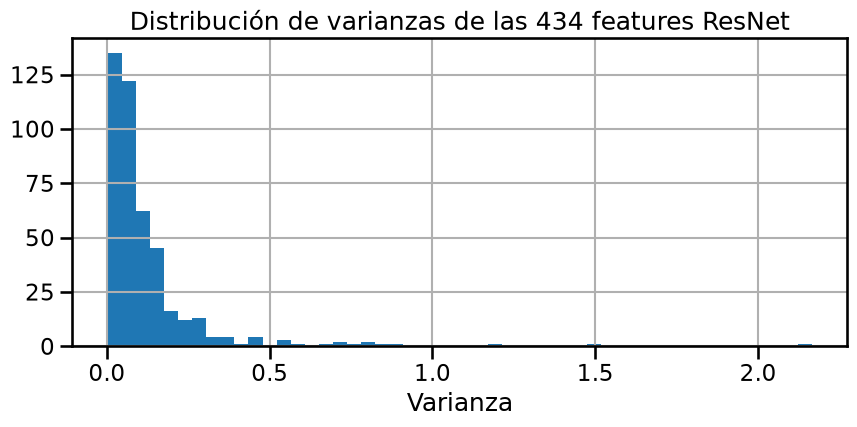

In [ ]:
# Analisis de las features de la ResNet
variances = train_df[resnet_cols].var().sort_values()
print("Features con menor varianza:")
print(variances.head(10))

plt.figure(figsize=(10,4))
plt.hist(variances, bins=50)
plt.title('Distribución de varianzas de las 434 features ResNet')
plt.xlabel('Varianza')
plt.grid()
plt.show()

La gran mayoría de las 434 features de la ResNet tiene varianza muy baja, solo algunas superan la varianza 0.5. En una red neuronal se esperan que muchas neuronas respondan débilmente o de forma casi constante ante la mayoría de imágenes, mientras que pocas concentran la mayor parte de la variabilidad útil.

In [ ]:
# Estudio de correlacion alta entre pares
corr_matrix = train_df[resnet_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, idx, upper.loc[idx, col])
                    for col in upper.columns for idx in upper.index
                    if pd.notna(upper.loc[idx, col]) and upper.loc[idx, col] > 0.9]
print(f"Pares de features con correlación > 0.9: {len(high_corr_pairs)}")

Pares de features con correlación > 0.9: 0


No se encontraron pares de features con correlación mayor a 0.9. Esto indica que las features de la ResNet no son redundantes entre sí y cada una aporta información distinta. No se elimina columnas por multicolinealidad.

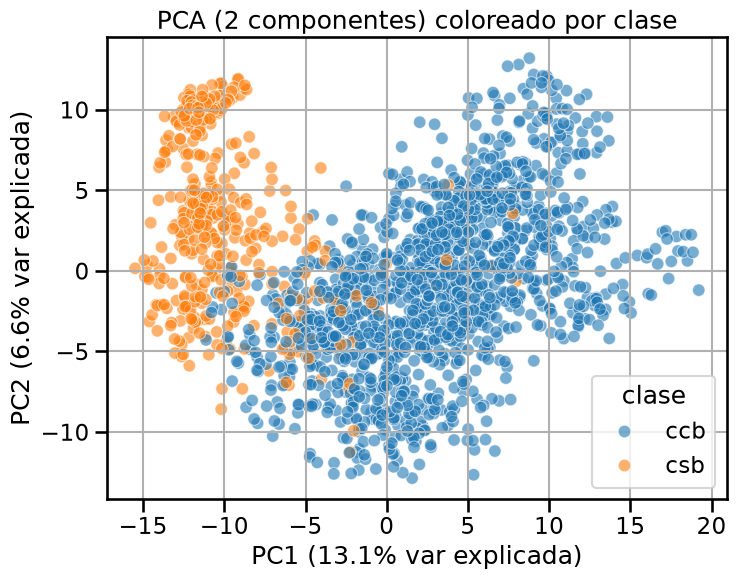

In [ ]:
# Visualizacion en baja dimension
X_vis = StandardScaler().fit_transform(train_df[resnet_cols])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_vis)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=train_df['clase'], alpha=0.6)
plt.title('PCA (2 componentes) coloreado por clase')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var explicada)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var explicada)')
plt.grid()
plt.show()

El PCA muestra una separación más marcada, gran parte de los puntos *csb* (naranja) se agrupan en una región bien diferenciada, mientras que *ccb* (azul) ocupa una región más amplia hacia la derecha y abajo. Hay una porción en la que ambos puntos se mezclan, por lo que la separación es parcial.

Los 2 componentes explican apenas el 19,7% de la varianza total.

In [ ]:
# Comparacion de distribucion train vs test
comparacion = pd.DataFrame({
    'train_mean': train_df[features_simples].mean(),
    'test_mean': test_df[features_simples].mean(),
    'train_std': train_df[features_simples].std(),
    'test_std': test_df[features_simples].std(),
})
comparacion

,train_mean,test_mean,train_std,test_std
bb_width,101.909236,101.909236,91.933372,91.933372
bb_height,133.479830,133.479830,119.158160,119.158160
ch_RGB,114.109534,114.109534,30.696614,30.696614


Se observa en `ch_RGB` la media (251.4) y el desvío estándar (1902) en test es más grande que la media (114.1) y el desvío estándar (30.7) train. Esto indica que el conjunto de test podría tener condiciones de iluminación o preprocesamiento distinto a los de train.

El Standarscaler debe ajustarse con los datos de train y luego aplicarse transform sobre test con esos mismo parámetros.

1475    202.392985
1306    202.117203
1506    199.123082
1882    197.059998
423     195.836578
389     195.663244
695     195.562500
1221    194.712763
1164    193.904872
770     193.065811
125     192.895381
1640    192.854914
103     192.757548
1170    192.495519
1025    191.953898
Name: ch_RGB, dtype: float64


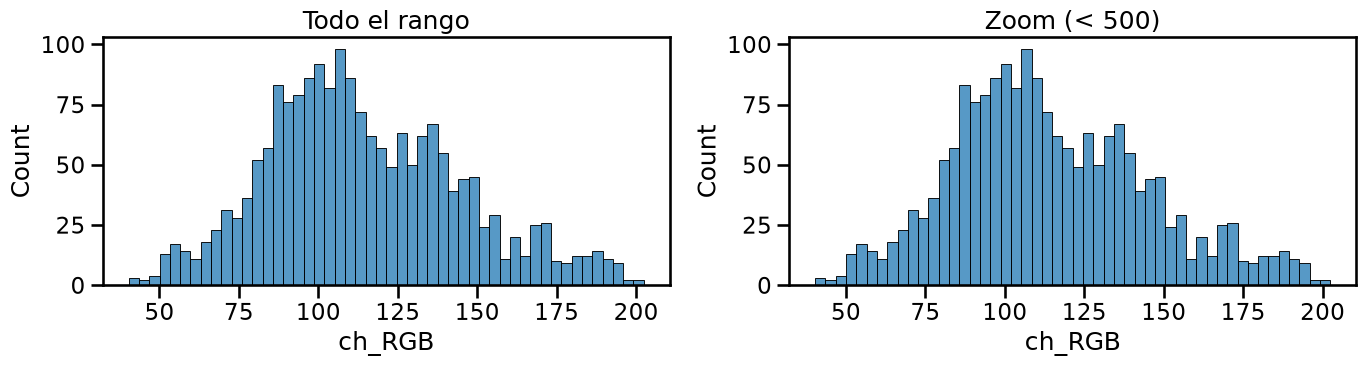

In [ ]:
# Ver los valores más altos de ch_RGB en test
print(test_df['ch_RGB'].sort_values(ascending=False).head(15))

# Comparar rango normal (zoom) vs completo
fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(test_df['ch_RGB'], bins=50, ax=axes[0])
axes[0].set_title('Todo el rango')

sns.histplot(test_df[test_df['ch_RGB'] < 500]['ch_RGB'], bins=50, ax=axes[1])
axes[1].set_title('Zoom (< 500)')
plt.tight_layout()
plt.show()

### 2.4 Codificacion de `clase`

In [ ]:
# Mapeo de valores. Valido porque estan acotadas
mapeo_directo = {'ccb': 1, 'csb': 0}
train_df['clase'] = train_df['clase'].map(mapeo_directo)

# Verificacion
train_df['clase'].value_counts()

clase
1    1436
0     448
Name: count, dtype: int64

### 2.3 Preparacion de datasets

In [ ]:
# Aislo la variable objetivo: clase
y = train_df.clase
X = train_df.drop('clase',axis=1)
X.head(3)

,id,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,1448,...,1152,1428,182,488,1369,582,570,2022,1966,198
0,1,118,167,126.002029,0.171342,0.254909,1.729943,0.872499,0.645055,0.141102,...,0.000246,0.081324,0.391930,0.247319,0.033110,0.394890,0.204616,1.668020,0.052727,0.302152
1,2,286,396,152.522842,0.172407,0.217375,2.900968,0.421334,0.270867,0.213251,...,0.056044,0.059036,0.123057,0.462978,0.037138,0.658777,0.172517,0.507375,0.274298,0.648528
2,3,123,167,93.290398,0.139690,0.759909,0.081340,0.325830,0.018619,0.170640,...,0.021488,0.350511,0.165781,0.114810,0.154125,0.193874,0.393903,0.170703,0.099427,0.344505


In [ ]:
# Separacion de la columna con los Id de las imágenes en una sola variable:
imagenID = X.id
X.drop('id',axis=1,inplace=True)

In [ ]:
# Estandarizado de variables:
x_names = X.columns
X = StandardScaler().fit_transform(X)
X = pd.DataFrame(X, columns=x_names)
X.head(3)

,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,1448,1843,...,1152,1428,182,488,1369,582,570,2022,1966,198
0,0.175073,0.281383,0.387523,0.026208,-0.532828,0.032379,2.697306,0.491393,-1.059764,-0.720381,...,-0.950096,-0.505110,0.843567,-0.608877,-0.598472,0.338203,-0.493066,2.129262,-1.467671,0.321267
1,2.002968,2.203709,1.251718,0.034641,-0.669883,0.992496,0.583859,-0.429723,-0.806275,-0.447428,...,-0.147339,-0.629339,-0.440919,0.165945,-0.552029,1.530114,-0.631851,-0.406197,0.436875,2.463745
2,0.229474,0.281383,-0.678403,-0.224577,1.311175,-1.319304,0.136473,-1.050667,-0.955986,-1.186158,...,-0.644487,0.995278,-0.236813,-1.084954,0.796811,-0.569734,0.325329,-1.141667,-1.066261,0.583238


Con esto, separamos los datasets de entrenamiento y testeo:

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state = 0, stratify=y)

In [ ]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 1507 entries, 1711 to 1608
Columns: 436 entries, bb_width to 198
dtypes: float64(436)
memory usage: 5.0 MB


In [ ]:
x_test.info()

<class 'pandas.DataFrame'>
Index: 377 entries, 726 to 306
Columns: 436 entries, bb_width to 198
dtypes: float64(436)
memory usage: 1.3 MB


**IMPORTANTE**: Luego de seleccionar el modelo, es necesario replicar el preprocesamiento anterior para el dataset de testeo `test_df` para evirar data leakage.

## 3. Planteo de modelos

De aca en adelante cada quien pruebe una serie de modelos con su respectiva exploracion de hiperparametros.

NOTA: Falta hacer el labeling de las filas que Agus filtró con el percentil 99.